 Capillary Bridge Force Analysis Notebook

# 1. Setup & Imports

In [1]:
import sys
from pathlib import Path
import json

cfg = json.load(open(r"Analysis_Files\config.json"))
image_dir = Path(cfg["image_dir"])
mask_dir  = Path(cfg["mask_dir"])
output_dir = Path(cfg["output_dir"])
lines_file = Path(cfg["lines_file"])
label_clf = Path(cfg["label_clf_path"])
side_clf  = Path(cfg["side_clf_path"])
excel_out = Path(cfg["output_dir"]) / cfg["excel_output"]
debug_dir = Path(cfg["output_dir"]) / cfg["debug_image_dir"]
first_frame_spacing = cfg["first_frame_spacing"]
sigma_surface_tension = cfg["sigma_surface_tension"]
print(type(image_dir), image_dir)

<class 'pathlib.WindowsPath'> D:\Capillary_bridging_data_alannah\Trial 1 (water on glass)\video


In [ ]:
#select new image folder path,and mask folder path, and output folder path
import tkinter as tk
from tkinter import filedialog
root = tk.Tk()
root.withdraw()  # Hide the root window
#keep the dialong on top
root.attributes('-topmost', True)

image_dir = Path(filedialog.askdirectory(title="Select Image Folder", initialdir=image_dir))
mask_dir = Path(filedialog.askdirectory(title="Select Mask Folder", initialdir=mask_dir))
output_dir = Path(filedialog.askdirectory(title="Select Output Folder", initialdir=output_dir))

#rewrite the config file with the new paths
cfg["image_dir"] = str(image_dir)
cfg["mask_dir"] = str(mask_dir)
cfg["output_dir"] = str(output_dir)
with open("Analysis_Files/config.json", "w") as f:
    json.dump(cfg, f, indent=4)
print(f"Image directory set to: {image_dir}")
print(f"Mask directory set to: {mask_dir}")
print(f"Output directory set to: {output_dir}")

# 2. Define Substrate Lines

In [2]:
%run -i Analysis_Files\Substrate_tests\define_substrate_lines.py


Selected frames: [0, 9, 10, 17, 20, 25, 30, 33]
Select TOP line for frame 0
Select BOTTOM line for frame 0
Select TOP line for frame 1
Select BOTTOM line for frame 1
Select TOP line for frame 2
Select BOTTOM line for frame 2
Select TOP line for frame 3
Select BOTTOM line for frame 3
Select TOP line for frame 4
Select BOTTOM line for frame 4
Select TOP line for frame 5
Select BOTTOM line for frame 5
Select TOP line for frame 6
Select BOTTOM line for frame 6
Select TOP line for frame 7
Select BOTTOM line for frame 7
Saved top_lines and bottom_lines to C:\Users\raglo\OneDrive - University of Arizona\Documents\GitHub\Capillary_Liquid_Bridges\Alannah_S1_substrates.npz


## 3. 

In [ ]:


# %%
# load lines
data = np.load(lines_file, allow_pickle=True)
top_lines = data['top_lines']
bottom_lines = data['bottom_lines']

# helper: load and draw
from define_substrate_lines import load_images_from_folder

def draw_frames_with_lines(image_folder, top_lines, bottom_lines):
    paths = load_images_from_folder(str(image_folder))
    frames = []
    for i, p in enumerate(paths):
        img = cv2.imread(p)
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if i < len(top_lines) and top_lines[i] is not None:
            cv2.line(rgb, tuple(top_lines[i][0]), tuple(top_lines[i][1]), (255,0,0), 2)
        if i < len(bottom_lines) and bottom_lines[i] is not None:
            cv2.line(rgb, tuple(bottom_lines[i][0]), tuple(bottom_lines[i][1]), (0,255,0), 2)
        frames.append((Path(p).name, rgb))
    return frames

frames = draw_frames_with_lines(image_dir, top_lines, bottom_lines)

# %%
# interactive slider viewer
from matplotlib.widgets import Slider
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.2)
img_disp = ax.imshow(frames[0][1])
ax.set_title(frames[0][0])
ax.axis('off')

ax_slider = plt.axes([0.25, 0.05, 0.5, 0.03])
slider = Slider(ax_slider, 'Frame', 0, len(frames)-1, valinit=0, valfmt='%0.0f')

def update(val):
    idx = int(slider.val)
    name, img = frames[idx]
    img_disp.set_data(img)
    ax.set_title(name)
    fig.canvas.draw_idle()

slider.on_changed(update)
plt.show()

# 3. Run Frame‐by‐Frame Analysis & Plot

Skipping frame 34: missing line data


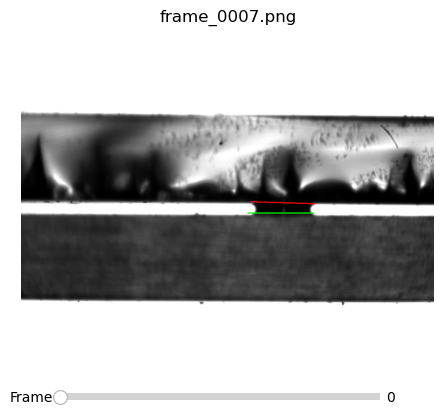

<Figure size 640x480 with 0 Axes>

In [6]:
%matplotlib inline
%run -i Analysis_Files\Substrate_tests\view_substrate_lines.py

# 4. Display Final Plot

In [ ]:
from IPython.display import Image
plot_path = Path(config.excel_output).with_suffix('.png')
Image(str(plot_path))


## Next Steps